## Process

In [1]:
from evolvepro.src.process import generate_wt, generate_single_aa_mutants
generate_wt('MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNTSSSPQPKKKPLDGEYFTLQIRGRERFEMFRELNEALELKDAQAGKEPGGSRAHSSHLKSKKGQSTSRHKKLMFKTEGPDSD', output_file='/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_WT_m.fasta')
generate_single_aa_mutants('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_WT_m.fasta', output_file='/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta')

Number of mutants: 7468


In [2]:
from evolvepro.src.process import suggest_initial_mutants
suggest_initial_mutants('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta', num_mutants=12, random_seed=42)


Suggested 12 mutants for testing:
1. E349P
2. R342E
3. V73E
4. R174M
5. T55R
6. S121I
7. P92D
8. A78V
9. K164G
10. G244N
11. K132M
12. A79Y


In [1]:
import pandas as pd
df_labels = pd.read_csv('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/embedding/giacomelli_labels.csv')
voi = 'H380N','G302N','H368N','G356Y','L323I','H365N','H296N','P36N','H115N','L323F'
max_activity = df_labels['activity'].max()
activity = df_labels[df_labels['variant'].isin(voi)]
print(max_activity)
print(activity)

2.533066897
     hgvs_pro PROVEAN PPH2_HumVar PPH2_HumDiv  Grantham  BLOSUM62 PhD_SNP  \
676      P36N      35          72         267        91        -2     103   
2157    H115N      92        0,01           0        68         1    0,45   
5596    H296N    1063           0           0        68         1      57   
5710    G302N    1132        0,49         827        80         0     195   
6103    L323F    -261         826        0,93        22         0     118   
6106    L323I   -0,11         295         655         5         2    0,06   
6744    G356Y     669         627         814       147        -3     168   
6907    H365N    -117         439         615        68         1     241   
6964    H368N       0        0,03          24        68         1     125   
7192    H380N     676           5           9        68         1     336   

     PANTHER SNPs&GO FATHMM  ... phyloP  phastCons DMS_WT_Nutlin  \
676      NaN     916  -5,43  ...    NaN        NaN  -0,224771662   
2157

## PLM

In [2]:
!python /home/tigem/m.livero/Desktop/EvolvePro/evolvepro/plm/esm/extract.py esm1b_t33_650M_UR50S /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/output_plm/giacomelli_esm1b_t33_650M_UR50S --toks_per_batch 512 --include mean --concatenate_dir /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/output_plm

Read /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta with 7468 sequences
Processing 1 of 7468 batches (1 sequences)
Device: cpu
Processing 2 of 7468 batches (1 sequences)
Device: cpu
Processing 3 of 7468 batches (1 sequences)
Device: cpu
Processing 4 of 7468 batches (1 sequences)
Device: cpu
Processing 5 of 7468 batches (1 sequences)
Device: cpu
Processing 6 of 7468 batches (1 sequences)
Device: cpu
Processing 7 of 7468 batches (1 sequences)
Device: cpu
Processing 8 of 7468 batches (1 sequences)
Device: cpu
Processing 9 of 7468 batches (1 sequences)
Device: cpu
Processing 10 of 7468 batches (1 sequences)
Device: cpu
Processing 11 of 7468 batches (1 sequences)
Device: cpu
Processing 12 of 7468 batches (1 sequences)
Device: cpu
Processing 13 of 7468 batches (1 sequences)
Device: cpu
Processing 14 of 7468 batches (1 sequences)
Device: cpu
Processing 15 of 7468 batches (1 sequences)
Device: cpu
Processing 16 of 7468 batches (1 seque

## Run EVOLVEpro

In [2]:
from evolvepro.src.evolve import evolve_experimental, directed_evolution_simulation, grid_search
from evolvepro.src.data import load_dms_data,load_experimental_embeddings,load_experimental_data,create_iteration_dataframes

protein_name = 'giacomelli'
embeddings_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/embedding'
embeddings_file_name = 'giacomelli_esm2_t33_650M_UR50D.csv'
round_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/'
wt_fasta_path = "/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/fasta/giacomelli_WT.fasta"
number_of_variants = 10
output_dir = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/plot'
rename_WT = False

#### Round 1

In [2]:
round_name = 'Round1'
round_file_names = ['Giacomelli_round0_exp.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round1
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round0_exp.xlsx: (10, 3)
iteration shape: (10, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7438,)

Tested variants in this round: 10
358      A78V
1455    E349P
1967    G244N
2703    K164G
4904     P92D
5292    R174M
5646    R342E
5764    S121I
6835     T55R
7166     V73E
Name: variant, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
6444   T102E  0.184468       NaN              NaN              NaN   
3992   N288D  0.174262       NaN              NaN              NaN   
6729   T304E  0.152692       NaN              NaN              NaN   
6443   T102D  0.151550       NaN              NaN              NaN   
3840   N131D  0.141494       NaN              NaN              NaN   
4012    N29E  0.139409       NaN              NaN              NaN   
4087   N345D  0.136653       NaN              NaN

#### Round 2

In [4]:
round_name = 'Round2'
round_file_names = ['Giacomelli_round1.xlsx', 'giacomelli_round2.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round2
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
iteration shape: (20, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7428,)

Tested variants in this round: 20
358      A78V
1455    E349P
1967    G244N
2703    K164G
3840    N131D
3992    N288D
3993    N288E
4012     N29E
4087    N345D
4088    N345E
4904     P92D
5292    R174M
5637    R337Q
5646    R342E
5764    S121I
6443    T102D
6444    T102E
6729    T304E
6835     T55R
7166     V73E
Name: variant, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
4848    P87E  0.303771       NaN              NaN              NaN   
439     A88E  0.269767       NaN              NaN              NaN   
4905    P92E  0.264971       NaN              NaN              NaN   
420     A86E  0.223269       NaN              NaN             

#### Round 3

In [9]:
round_name = 'Round3'
round_file_names = ['Giacomelli_round1.xlsx', 'giacomelli_round2.xlsx', 'giacomelli_round3.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round3
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
iteration shape: (30, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7418,)

Tested variants in this round: 30
287      A70E
358      A78V
420      A86E
439      A88E
1455    E349P
1967    G244N
2703    K164G
3840    N131D
3879    N210E
3992    N288D
3993    N288E
4012     N29E
4087    N345D
4088    N345E
4430    P300E
4639      P4E
4734     P71E
4848     P87E
4904     P92D
4905     P92E
5292    R174M
5637    R337Q
5646    R342E
5764    S121I
6349     S94E
6443    T102D
6444    T102E
6729    T304E
6835     T55R
7166     V73E
Name: variant, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
4867    P89E  0.647084       NaN              NaN              NaN   
6

#### Round 4

In [12]:
round_name = 'Round4'
round_file_names = ['Giacomelli_round1.xlsx', 'giacomelli_round2.xlsx', 'giacomelli_round3.xlsx', 'giacomelli_round4.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round4
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
iteration shape: (40, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7408,)

Tested variants in this round: 40
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
439      A88E
1455    E349P
1967    G244N
2262    H168C
2703    K164G
3840    N131D
3879    N210E
3992    N288D
3993    N288E
4012     N29E
4087    N345D
4088    N345E
4430    P300E
4449    P301E
4577    P359W
4639      P4E
4734     P71E
4848     P87E
4865     P89C
4867     P89E
4904     P92D
4905     P92E
5171     Q38E
5292    R174M
5637    R337Q
5646    R342E
5764    S121I
6064    S313E
6330     S90E
6349     S94E
6443    T102D
6444    T102E
6729    T304E
6835     T55R
7166     V73E
Name: v

#### Round 5

In [14]:
round_name = 'Round5'
round_file_names = ['Giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round5
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5.xlsx: (10, 3)
iteration shape: (50, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7398,)

Tested variants in this round: 50
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
439      A88E
1455    E349P
1967    G244N
2262    H168C
2449    H368W
2468    H380W
2703    K164G
3840    N131D
3879    N210E
3992    N288D
3993    N288E
4012     N29E
4087    N345D
4088    N345E
4204    P152G
4430    P300E
4449    P301E
4577    P359W
4615    P390W
4639      P4E
4693     P64A
4734     P71E
4747     P71V
4848     P87E
4865     P89C
4866     P89D
4867     P89E
4880     P89V
4904     P92D
4905     P92E
5171     Q38E
52

Round 6


In [21]:
round_name = 'Round6'
round_file_names = ['Giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx',
                    'giacomelli_round6.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round6
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6.xlsx: (10, 3)
iteration shape: (60, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7388,)

Tested variants in this round: 60
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
439      A88E
1455    E349P
1967    G244N
2145    G356W
2193    G374L
2201    G374V
2262    H168C
2430    H365W
2449    H368W
2468    H380W
2703    K164G
3209     L22W
3840    N131D
3879    N210E
3992    N288D
3993    N288E
4012     N29E
4087    N345D
4088    N345E
4204    P152G
4430    P300E
4449    P301E
4450    P301F
4577    P359W
4615    P390W
4639      P4E
4693     P6

Round 7

In [26]:
round_name = 'Round7'
round_file_names = ['Giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx',
                    'giacomelli_round6.xlsx',
                    'giacomelli_round7.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round7
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7.xlsx: (10, 3)
iteration shape: (70, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7378,)

Tested variants in this round: 70
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
        ...  
6747    T312D
6790    T377I
6799    T377V
6835     T55R
7166     V73E
Name: variant, Length: 70, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
2191   G374I  0.869736       NaN              NaN              NaN   
2195   G374

Round 8

In [28]:
round_name = 'Round8'
round_file_names = ['Giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx',
                    'giacomelli_round6.xlsx',
                    'giacomelli_round7.xlsx',
                    'giacomelli_round8.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round8
Embeddings loaded: (7448, 1280)
Loaded experimental data for Giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7.xlsx: (10, 3)
Loaded experimental data for giacomelli_round8.xlsx: (10, 3)
iteration shape: (80, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7368,)

Tested variants in this round: 80
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
        ...  
6792    T377L
6799    T377V
6801    T377Y
6835     T55R
7166     V73E
Name: variant, Length: 80, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
2197   G374Q  1.0945

Round 9

In [2]:
round_name = 'Round9'
round_file_names = ['giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx',
                    'giacomelli_round6.xlsx',
                    'giacomelli_round7.xlsx',
                    'giacomelli_round8.xlsx',
                    'giacomelli_round9.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round9
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7.xlsx: (10, 3)
Loaded experimental data for giacomelli_round8.xlsx: (10, 3)
Loaded experimental data for giacomelli_round9.xlsx: (10, 3)
iteration shape: (90, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7358,)

Tested variants in this round: 90
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
        ...  
6792    T377L
6799    T377V
6801    T377Y
6835     T55R
7166     V73E
Name: variant, Length: 90, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_act

Round 10

In [5]:
round_name = 'Round10'
round_file_names = ['giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx',
                    'giacomelli_round6.xlsx',
                    'giacomelli_round7.xlsx',
                    'giacomelli_round8.xlsx',
                    'giacomelli_round9.xlsx',
                    'giacomelli_round10.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round10
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7.xlsx: (10, 3)
Loaded experimental data for giacomelli_round8.xlsx: (10, 3)
Loaded experimental data for giacomelli_round9.xlsx: (10, 3)
Loaded experimental data for giacomelli_round10.xlsx: (10, 3)
iteration shape: (100, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7348,)

Tested variants in this round: 100
135     A307E
287      A70E
344      A78E
358      A78V
420      A86E
        ...  
6792    T377L
6799    T377V
6801    T377Y
6835     T55R
7166     V73E
Name: variant, Length: 100, dtype: str

Top

## Plot

In [4]:
from evolvepro.src.plot import read_exp_data, plot_variants_by_iteration

round_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/File_round/1st_replicate'
round_file_names = ['giacomelli_round1.xlsx', 
                    'giacomelli_round2.xlsx', 
                    'giacomelli_round3.xlsx', 
                    'giacomelli_round4.xlsx',
                    'giacomelli_round5.xlsx',
                    'giacomelli_round6.xlsx',
                    'giacomelli_round7.xlsx',
                    'giacomelli_round8.xlsx',
                    'giacomelli_round9.xlsx',
                    'giacomelli_round10.xlsx']
wt_fasta_path = "/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/fasta/giacomelli_WT_m.fasta"

   Variant  activity variant  iteration
0     349P -1.625905   E349P        1.0
1     342E -0.275362   R342E        1.0
2      73E  0.615163    V73E        1.0
3     174M  0.790948   R174M        1.0
4      55R  0.277404    T55R        1.0
..     ...       ...     ...        ...
95    365N  0.853772   H365N       10.0
96    296N  0.483199   H296N       10.0
97     36N  1.041486    P36N       10.0
98    115N  0.528652   H115N       10.0
99    323F  0.864320   L323F       10.0

[100 rows x 4 columns]


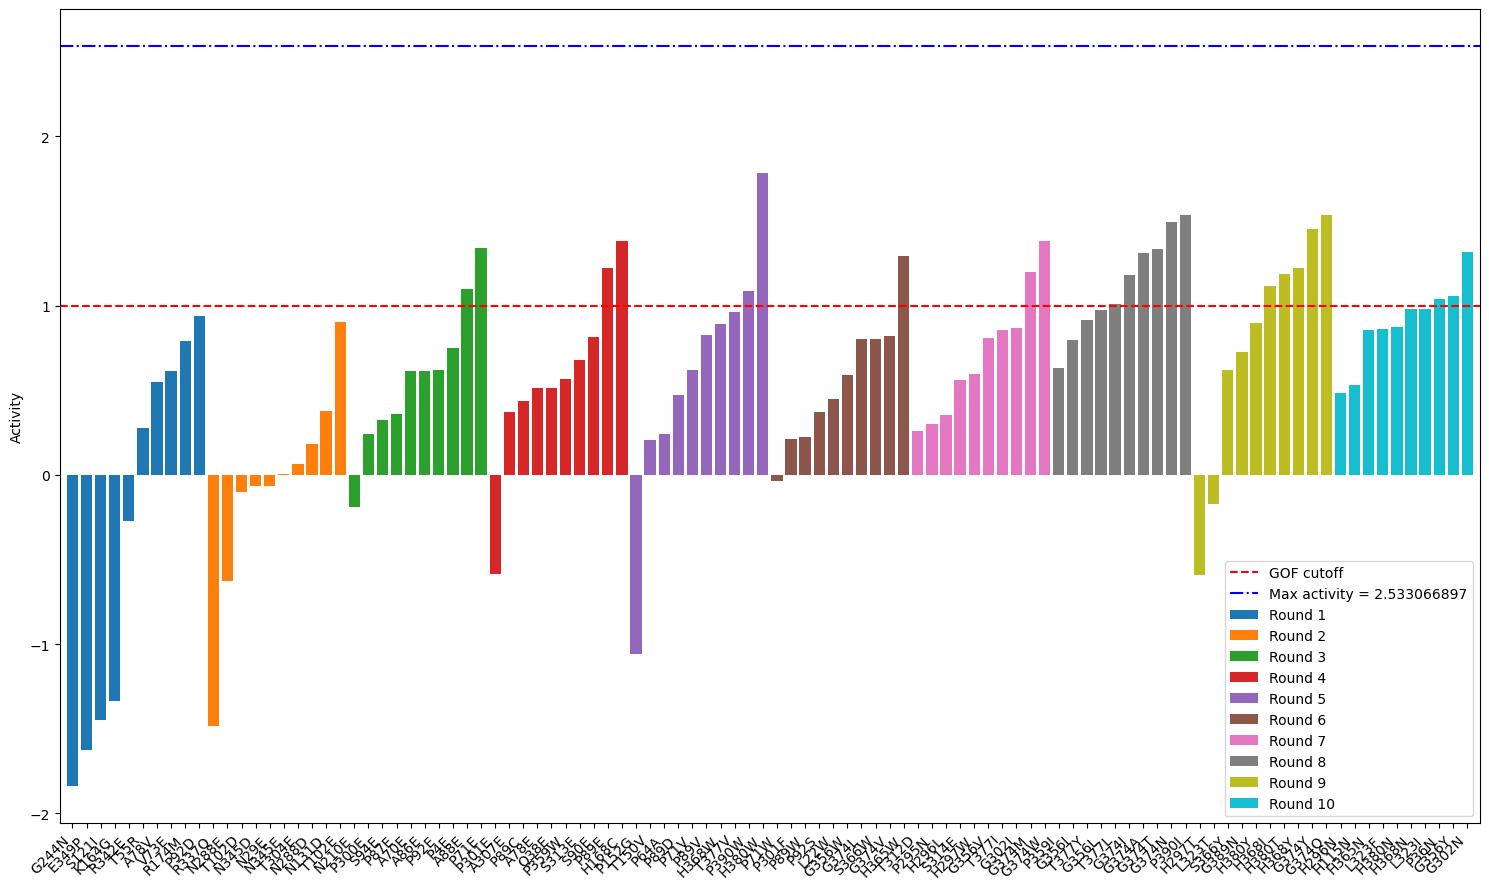

In [ ]:
df = read_exp_data(round_base_path, round_file_names, wt_fasta_path)

print(df)
plot_variants_by_iteration(df,df_labels, activity_column='activity', output_dir=output_dir, output_file="giacomelli")


In [33]:
from evolvepro.src.metrics_functions import load_dataset, enrichment_factor, apk

#round1
round_path_1 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round1/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_1 = load_dataset(round_path_1, path_labels, threshold_hit=1.0)
ef_r1 = enrichment_factor(df_giacomelli_1, fraction=0.1)
ap_10_r1 = apk(df_giacomelli_1, k=10)
print(f'Enrichment Factor(0.1) Round 1: {ef_r1}')
print(f'Average Precision@10 Round 1: {ap_10_r1}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   R174M  0.355522  0.790948         0.947377              0.0   
1           1    P92D  0.337826  0.937027         1.000000              0.0   
2           2   T102E  0.184468       NaN              NaN              NaN   
3           3   N288D  0.174262       NaN              NaN              NaN   
4           4   T304E  0.152692       NaN              NaN              NaN   
5           5   T102D  0.151550       NaN              NaN              NaN   
6           6   N131D  0.141494       NaN              NaN              NaN   
7           7    N29E  0.139409       NaN              NaN              NaN   
8           8   N345D  0.136653       NaN              NaN              NaN   
9           9    V73E  0.128981  0.615163         0.884053              0.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.038435              0.0  0.790948                0  
1     0.

In [34]:
#round2
round_path_2 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round2/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_2 = load_dataset(round_path_2, path_labels, threshold_hit=1.0)
ef_r2 = enrichment_factor(df_giacomelli_2, fraction=0.1)
ap_10_r2 = apk(df_giacomelli_2, k=10)
print(f'Enrichment Factor(0.1) Round 2: {ef_r2}')
print(f'Average Precision@10 Round 2: {ap_10_r2}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   T102E  0.643009  0.901531         0.987213              0.0   
1           1    P92D  0.421282  0.937027         1.000000              0.0   
2           2   R174M  0.360527  0.790948         0.947377              0.0   
3           3    P87E  0.303771       NaN              NaN              NaN   
4           4    V73E  0.293080  0.615163         0.884053              0.0   
5           5    A88E  0.269767       NaN              NaN              NaN   
6           6    P92E  0.264971       NaN              NaN              NaN   
7           7    A86E  0.223269       NaN              NaN              NaN   
8           8    S94E  0.210688       NaN              NaN              NaN   
9           9   P300E  0.199784       NaN              NaN              NaN   

   dist_metric  std_predictions  activity  activity_binary  
0     0.031703              0.0  0.901531                0  
1     0.

In [37]:
#round3
round_path_3 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round3/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_3 = load_dataset(round_path_3, path_labels, threshold_hit=1.0)
ef_r3 = enrichment_factor(df_giacomelli_3, fraction=0.1)
ap_10_r3 = apk(df_giacomelli_3, k=10)
print(f'Enrichment Factor(0.1) Round 3: {ef_r3}')
print(f'Average Precision@10 Round 3: {ap_10_r3}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0    P71E  1.081100  1.342116         1.000000              1.0   
1           1    A88E  0.911558  1.098468         0.923406              1.0   
2           2   T102E  0.663577  0.901531         0.861496              0.0   
3           3    P92D  0.653507  0.937027         0.872655              0.0   
4           4    P89E  0.647084       NaN              NaN              NaN   
5           5     P4E  0.635101  0.752063         0.814509              0.0   
6           6    S90E  0.631330       NaN              NaN              NaN   
7           7    A86E  0.603773  0.613302         0.770888              0.0   
8           8    A70E  0.603169  0.611800         0.770416              0.0   
9           9    P92E  0.589106  0.618293         0.772457              0.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.035792              0.0  1.342116                1  
1     0.

In [38]:
#round4
round_path_4 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round4/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_4 = load_dataset(round_path_4, path_labels, threshold_hit=1.0)
ef_r4 = enrichment_factor(df_giacomelli_4, fraction=0.1)
ap_10_r4 = apk(df_giacomelli_4, k=10)
print(f'Enrichment Factor(0.1) Round 4: {ef_r4}')
print(f'Average Precision@10 Round 4: {ap_10_r4}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0    P89E  1.108954  1.219024         0.949553              1.0   
1           1    P71E  1.107520  1.342116         0.987776              1.0   
2           2   H168C  1.011470  1.381483         1.000000              1.0   
3           3    A88E  0.930485  1.098468         0.912118              1.0   
4           4    S90E  0.711564  0.813407         0.823601              0.0   
5           5    P92D  0.680234  0.937027         0.861988              0.0   
6           6   H380W  0.678491       NaN              NaN              NaN   
7           7    P71V  0.676420       NaN              NaN              NaN   
8           8   H368W  0.663154       NaN              NaN              NaN   
9           9     P4E  0.653619  0.752063         0.804553              0.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.035037              0.0  1.219024                1  
1     0.

In [39]:
#round5
round_path_5 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round5/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_5 = load_dataset(round_path_5, path_labels, threshold_hit=1.0)
ef_r5 = enrichment_factor(df_giacomelli_5, fraction=0.1)
ap_10_r5 = apk(df_giacomelli_5, k=10)
print(f'Enrichment Factor(0.1) Round 5: {ef_r5}')
print(f'Average Precision@10 Round 5: {ap_10_r5}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H380W  1.478853  1.780901         1.000000              1.0   
1           1    P71E  1.120595  1.342116         0.878783              1.0   
2           2    P89E  1.027038  1.219024         0.844778              1.0   
3           3   H168C  1.002130  1.381483         0.889658              1.0   
4           4    A88E  0.940740  1.098468         0.811473              1.0   
5           5   H368W  0.939263  0.892990         0.754709              0.0   
6           6   P390W  0.886437  1.085360         0.807852              1.0   
7           7    P92D  0.774606  0.937027         0.766874              0.0   
8           8    P89W  0.756501       NaN              NaN              NaN   
9           9   T377V  0.733479  0.963896         0.774297              0.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.032707              0.0  1.780901                1  
1     0.

In [40]:
#round6
round_path_6 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round6/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_6 = load_dataset(round_path_6, path_labels, threshold_hit=1.0)
ef_r6 = enrichment_factor(df_giacomelli_6, fraction=0.1)
ap_10_r6 = apk(df_giacomelli_6, k=10)
print(f'Enrichment Factor(0.1) Round 6: {ef_r6}')
print(f'Average Precision@10 Round 6: {ap_10_r6}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H380W  1.393736  1.780901         1.000000              1.0   
1           1   H365W  1.102493  1.295695         0.865959              1.0   
2           2    P71E  1.039265  1.342116         0.878783              1.0   
3           3   H368W  0.999808  0.892990         0.754709              0.0   
4           4    P89E  0.985657  1.219024         0.844778              1.0   
5           5   H168C  0.971125  1.381483         0.889658              1.0   
6           6    A88E  0.925100  1.098468         0.811473              1.0   
7           7   S366W  0.813800  0.800750         0.729227              0.0   
8           8    P92D  0.807227  0.937027         0.766874              0.0   
9           9   G374V  0.799384  0.819452         0.734393              0.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.032707              0.0  1.780901                1  
1     0.

In [41]:
#round7
round_path_7 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round7/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_7 = load_dataset(round_path_7, path_labels, threshold_hit=1.0)
ef_r7 = enrichment_factor(df_giacomelli_7, fraction=0.1)
ap_10_r7 = apk(df_giacomelli_7, k=10)
print(f'Enrichment Factor(0.1) Round 7: {ef_r7}')
print(f'Average Precision@10 Round 7: {ap_10_r7}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H380W  1.386380  1.780901         1.000000              1.0   
1           1   G374W  1.112675  1.380802         0.889470              1.0   
2           2   G374M  1.092713  1.200461         0.839650              1.0   
3           3   H365W  1.084673  1.295695         0.865959              1.0   
4           4    P71E  1.075087  1.342116         0.878783              1.0   
5           5   H168C  1.051909  1.381483         0.889658              1.0   
6           6   H368W  0.964113  0.892990         0.754709              0.0   
7           7   P390W  0.935573  1.085360         0.807852              1.0   
8           8    P89E  0.926763  1.219024         0.844778              1.0   
9           9    A88E  0.896269  1.098468         0.811473              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.032707              0.0  1.780901                1  
1     0.

In [42]:
#round5
round_path_8 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round8/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_8 = load_dataset(round_path_8, path_labels, threshold_hit=1.0)
ef_r8 = enrichment_factor(df_giacomelli_8, fraction=0.1)
ap_10_r8 = apk(df_giacomelli_8, k=10)
print(f'Enrichment Factor(0.1) Round 8: {ef_r8}')
print(f'Average Precision@10 Round 8: {ap_10_r8}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H380W  1.464215  1.780901         1.000000              1.0   
1           1   G374N  1.349970  1.493279         0.920543              1.0   
2           2   G374T  1.252305  1.333307         0.876349              1.0   
3           3   G374W  1.215087  1.380802         0.889470              1.0   
4           4   G374A  1.177326  1.309104         0.869663              1.0   
5           5   P390I  1.175596  1.535477         0.932200              1.0   
6           6   G374M  1.162890  1.200461         0.839650              1.0   
7           7    P71E  1.143317  1.342116         0.878783              1.0   
8           8   G374I  1.129101  1.180166         0.834043              1.0   
9           9   H168C  1.096722  1.381483         0.889658              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.032707              0.0  1.780901                1  
1     0.

In [43]:
#round9
round_path_9 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round9/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_9 = load_dataset(round_path_9, path_labels, threshold_hit=1.0)
ef_r9 = enrichment_factor(df_giacomelli_9, fraction=0.1)
ap_10_r9 = apk(df_giacomelli_9, k=10)
print(f'Enrichment Factor(0.1) Round 9: {ef_r9}')
print(f'Average Precision@10 Round 9: {ap_10_r9}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H380W  1.489050  1.780901         1.000000              1.0   
1           1   G374Q  1.345094  1.534220         0.931853              1.0   
2           2   G374N  1.295841  1.493279         0.920543              1.0   
3           3   G374W  1.274961  1.380802         0.889470              1.0   
4           4   G374Y  1.257792  1.452188         0.909191              1.0   
5           5   G374T  1.237500  1.333307         0.876349              1.0   
6           6   G374A  1.186963  1.309104         0.869663              1.0   
7           7   P390I  1.178229  1.535477         0.932200              1.0   
8           8   H365W  1.173390  1.295695         0.865959              1.0   
9           9   G374M  1.140989  1.200461         0.839650              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.032707              0.0  1.780901                1  
1     0.

In [44]:
#round10
round_path_10 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli/Round10/df_sorted_all.csv'
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_labels.csv'
df_giacomelli_10 = load_dataset(round_path_10, path_labels, threshold_hit=1.0)
ef_r10 = enrichment_factor(df_giacomelli_10, fraction=0.1)
ap_10_r10 = apk(df_giacomelli_10, k=10)
print(f'Enrichment Factor(0.1) Round 10: {ef_r10}')
print(f'Average Precision@10 Round 10: {ap_10_r10}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H380W  1.347514  1.780901         1.000000              1.0   
1           1   G374N  1.339737  1.493279         0.920543              1.0   
2           2   G374Q  1.328943  1.534220         0.931853              1.0   
3           3   P390I  1.295667  1.535477         0.932200              1.0   
4           4   G374Y  1.288671  1.452188         0.909191              1.0   
5           5   G374W  1.276046  1.380802         0.889470              1.0   
6           6   G374T  1.201019  1.333307         0.876349              1.0   
7           7   H365W  1.155409  1.295695         0.865959              1.0   
8           8   G374A  1.146589  1.309104         0.869663              1.0   
9           9   G302N  1.137895  1.315310         0.871377              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.032707              0.0  1.780901                1  
1     0.

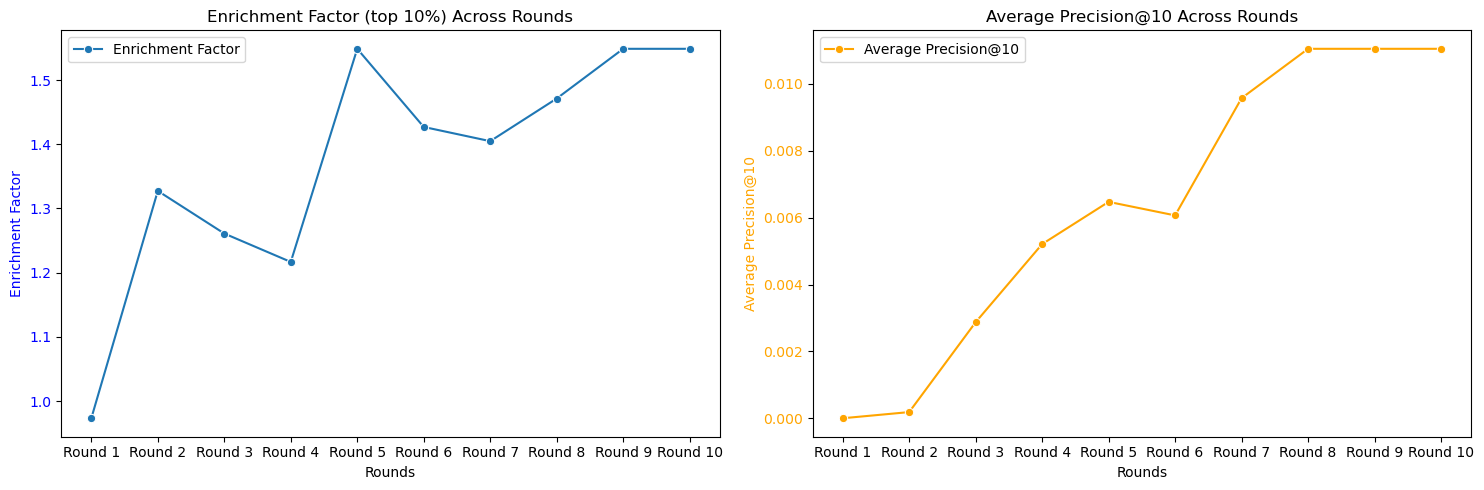

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt 
rounds = ['Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5', 'Round 6', 'Round 7', 'Round 8', 'Round 9', 'Round 10']
ef_values = [ef_r1, ef_r2, ef_r3, ef_r4, ef_r5, ef_r6, ef_r7, ef_r8, ef_r9, ef_r9]
apk_values = [ap_10_r1, ap_10_r2, ap_10_r3, ap_10_r4, ap_10_r5, ap_10_r6, ap_10_r7, ap_10_r8, ap_10_r9, ap_10_r10]

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(15, 5))
sns.lineplot(x=rounds, y=ef_values, marker='o', label='Enrichment Factor', ax=ax1)
ax1.set_title('Enrichment Factor (top 10%) Across Rounds')
ax1.set_xlabel('Rounds')
ax1.set_ylabel('Enrichment Factor', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


sns.lineplot(x=rounds, y=apk_values, marker='o', label='Average Precision@10', ax=ax2, color='orange')
ax2.set_title('Average Precision@10 Across Rounds')
ax2.set_xlabel('Rounds')
ax2.set_ylabel('Average Precision@10', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
fig.tight_layout()
plt.savefig(
    '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/EF_APK_giacomelli_mio.png', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

In [ ]:
from evolvepro.src.evolve import evolve_experimental, directed_evolution_simulation, grid_search
from evolvepro.src.data import load_dms_data,load_experimental_embeddings,load_experimental_data,create_iteration_dataframes

protein_name = 'giacomelli'
embeddings_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/'
embeddings_file_name = 'giacomelli_esm2_t33_650M_UR50D.csv'
round_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/'
wt_fasta_path = "/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_process/giacomelli_WT.fasta"
number_of_variants = 10
output_dir = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/'
rename_WT = False